## import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## load data

In [2]:
orders = pd.read_csv("olist_orders_dataset.csv")
order_items = pd.read_csv( "olist_order_items_dataset.csv")
customers = pd.read_csv( "olist_customers_dataset.csv")
products = pd.read_csv( "olist_products_dataset.csv")
payments = pd.read_csv("olist_order_payments_dataset.csv")
reviews = pd.read_csv( "olist_order_reviews_dataset.csv")
sellers = pd.read_csv( "olist_sellers_dataset.csv")
category_translation = pd.read_csv("product_category_name_translation.csv")

In [3]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [4]:
datasets = {
    "orders": orders,
    "order_items": order_items,
    "customers": customers,
    "products": products,
    "payments": payments,
    "reviews": reviews,
    "sellers": sellers,
    "category_translation": category_translation
}

for name, df in datasets.items():
    print(f"{name}: {df.shape}")


orders: (99441, 8)
order_items: (112650, 7)
customers: (99441, 5)
products: (32951, 9)
payments: (103886, 5)
reviews: (99224, 7)
sellers: (3095, 4)
category_translation: (71, 2)


# Understanding Tables

In [5]:
for name, df in datasets.items():
    print(f"\n{name.upper()}")
    df.info()



ORDERS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB

ORDER_ITEMS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112

In [6]:
orders.describe(include="all").T


,count,unique,top,freq
order_id,99441,99441,e481f51cbdc54678b7cc49136f2d6af7,1
customer_id,99441,99441,9ef432eb6251297304e76186b10a928d,1
order_status,99441,8,delivered,96478
order_purchase_timestamp,99441,98875,2018-04-11 10:48:14,3
order_approved_at,99281,90733,2018-02-27 04:31:10,9
order_delivered_carrier_date,97658,81018,2018-05-09 15:48:00,47
order_delivered_customer_date,96476,95664,2018-05-08 23:38:46,3
order_estimated_delivery_date,99441,459,2017-12-20 00:00:00,522


In [7]:
print("Orders:", orders["order_id"].nunique())
print("Order-item orders:", order_items["order_id"].nunique())
print("Unique customers:", customers["customer_unique_id"].nunique())
print("Sellers:", sellers["seller_id"].nunique())
print("Products:", products["product_id"].nunique())


Orders: 99441
Order-item orders: 98666
Unique customers: 96096
Sellers: 3095
Products: 32951


# Cheking Missing Values 

In [8]:
def missing_value_report(df):
    report = pd.DataFrame({
        "missing_count": df.isna().sum(),
        "missing_percent": df.isna().mean().mul(100)
    })

    return report[report["missing_count"] > 0].sort_values(
        "missing_percent",
        ascending=False
    )

for name, df in datasets.items():
    print(f"\n{name.upper()}")
    display(missing_value_report(df))



ORDERS


,missing_count,missing_percent
order_delivered_customer_date,2965,2.981668
order_delivered_carrier_date,1783,1.793023
order_approved_at,160,0.160899



ORDER_ITEMS


,missing_count,missing_percent



CUSTOMERS


...

,missing_count,missing_percent
review_comment_title,87656,88.341530
review_comment_message,58247,58.702532



SELLERS


,missing_count,missing_percent



CATEGORY_TRANSLATION


,missing_count,missing_percent


# Check Duplicates

In [9]:

for name, df in datasets.items():
    print(name, df.duplicated().sum())


orders 0
order_items 0
customers 0
products 0
payments 0
reviews 0
sellers 0
category_translation 0


In [10]:
print("Duplicate order IDs:", orders["order_id"].duplicated().sum())
print("Duplicate customer IDs:", customers["customer_id"].duplicated().sum())
print("Duplicate product IDs:", products["product_id"].duplicated().sum())
print("Duplicate seller IDs:", sellers["seller_id"].duplicated().sum())


Duplicate order IDs: 0
Duplicate customer IDs: 0
Duplicate product IDs: 0
Duplicate seller IDs: 0


In [11]:
print(order_items["order_id"].duplicated().sum())
print(payments["order_id"].duplicated().sum())
print(reviews["order_id"].duplicated().sum())


13984
4446
551


# check primary keys

In [13]:
order_date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for column in order_date_columns:
    orders[column] = pd.to_datetime(orders[column], errors="coerce")

order_items["shipping_limit_date"] = pd.to_datetime(
    order_items["shipping_limit_date"],
    errors="coerce"
)


# check logic errors

In [12]:
print("Negative prices:", (order_items["price"] < 0).sum())
print("Negative freight:", (order_items["freight_value"] < 0).sum())
print("Invalid reviews:", (~reviews["review_score"].between(1, 5)).sum())


Negative prices: 0
Negative freight: 0
Invalid reviews: 0


# Convert Dates

In [14]:
orders["purchase_date"] = orders["order_purchase_timestamp"].dt.date
orders["purchase_month"] = (
    orders["order_purchase_timestamp"]
    .dt.to_period("M")
    .dt.to_timestamp()
)
orders["purchase_year"] = orders["order_purchase_timestamp"].dt.year
orders["purchase_day_name"] = orders["order_purchase_timestamp"].dt.day_name()
orders["purchase_hour"] = orders["order_purchase_timestamp"].dt.hour


# Analysis Table

## Table A: Order_level Table 
- Use this for:
- Number of orders.
- Customer analysis.
- Order status.
- Delivery analysis.
- Reviews.

In [15]:
products = products.merge(
    category_translation,
    on="product_category_name",
    how="left",
    validate="many_to_one"
)

products["product_category_name_english"] = (
    products["product_category_name_english"]
    .fillna(products["product_category_name"])
    .fillna("unknown")
)


In [16]:
review_per_order = (
    reviews.groupby("order_id", as_index=False)
    .agg(
        review_score=("review_score", "mean"),
        review_count=("review_id", "nunique")
    )
)


In [17]:
order_level = (
    orders
    .merge(
        customers,
        on="customer_id",
        how="left",
        validate="many_to_one"
    )
    .merge(
        review_per_order,
        on="order_id",
        how="left",
        validate="one_to_one"
    )
)

print(order_level.shape)
print(order_level["order_id"].nunique())


(99441, 19)
99441


## Table B: Item-Level Table
- Use this for:
- Product revenue.
- Product-category performance.
- Seller performance.
- Freight analysis.

In [18]:
item_level = (
    order_items
    .merge(
        products[
            ["product_id", "product_category_name_english"]
        ],
        on="product_id",
        how="left",
        validate="many_to_one"
    )
    .merge(
        sellers,
        on="seller_id",
        how="left",
        validate="many_to_one"
    )
    .merge(
        orders[
            ["order_id", "order_purchase_timestamp",
             "purchase_month", "order_status"]
        ],
        on="order_id",
        how="left",
        validate="many_to_one"
    )
)


# kpi.
## KPI Definitions

- Orders: Distinct delivered order IDs unless otherwise specified.
- Product Revenue: Sum of item prices.
- Freight Revenue/Charge: Sum of freight values.
- Gross Order Value: Product price plus freight.
- Average Order Value: Product revenue divided by distinct orders.
- Late Delivery Rate: Percentage of delivered orders arriving after the estimated date.
- Repeat Customer Rate: Percentage of unique customers with more than one order.
- Average Review Score: Mean review score across reviewed orders.

# Analysis Order status

In [19]:
order_status_summary = (
    orders["order_status"]
    .value_counts()
    .rename_axis("order_status")
    .reset_index(name="orders")
)

order_status_summary["percentage"] = (
    order_status_summary["orders"]
    / order_status_summary["orders"].sum()
    * 100
)

order_status_summary


,order_status,orders,percentage
0,delivered,96478,97.020344
1,shipped,1107,1.113223
2,canceled,625,0.628513
3,unavailable,609,0.612423
4,invoiced,314,0.315765
5,processing,301,0.302692
6,created,5,0.005028
7,approved,2,0.002011


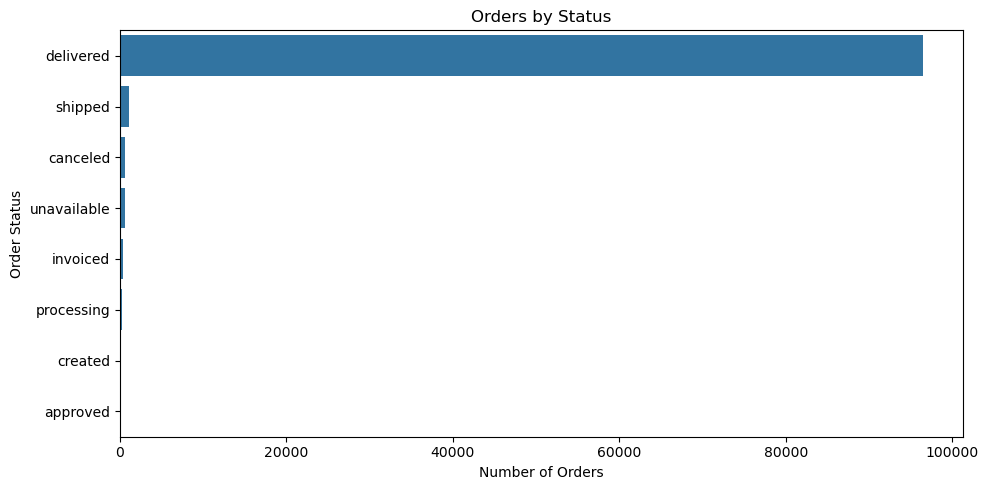

In [20]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=order_status_summary,
    x="orders",
    y="order_status"
)

plt.title("Orders by Status")
plt.xlabel("Number of Orders")
plt.ylabel("Order Status")
plt.tight_layout()
plt.show()


In [21]:

FAILED_STATUSES = ["canceled", "unavailable"]

# تاریخ‌ها
orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"], errors="coerce")
orders["purchase_month"] = orders["order_purchase_timestamp"].dt.to_period("M").dt.to_timestamp()

# فلگ سفارش ناموفق
orders["is_failed"] = orders["order_status"].isin(FAILED_STATUSES)


In [22]:
seller_order_level = (
    order_items[["order_id", "seller_id"]]
    .drop_duplicates()
    .merge(
        orders[["order_id", "order_status", "is_failed"]],
        on="order_id",
        how="left"
    )
)

seller_failure = (
    seller_order_level
    .groupby("seller_id", as_index=False)
    .agg(
        total_orders=("order_id", "nunique"),
        failed_orders=("is_failed", "sum")
    )
)

seller_failure["failure_rate"] = (
    seller_failure["failed_orders"] / seller_failure["total_orders"] * 100
)

# sellerهایی که بیشترین تعداد سفارش ناموفق را دارند
top_sellers_by_failed_count = (
    seller_failure
    .sort_values(["failed_orders", "failure_rate"], ascending=[False, False])
    .head(20)
)

# sellerهایی که بدترین نرخ failure را دارند
# حداقل آستانه می‌گذاریم تا sellerهای خیلی کوچک گمراه نکنند
top_sellers_by_failed_rate = (
    seller_failure[seller_failure["total_orders"] >= 20]
    .sort_values(["failure_rate", "failed_orders"], ascending=[False, False])
    .head(20)
)

top_sellers_by_failed_count
top_sellers_by_failed_rate


,seller_id,total_orders,failed_orders,failure_rate
3094,ffff564a4f9085cd26170f4732393726,20,4,20.000000
914,4c8b8048e33af2bf94f2eb547746a916,23,4,17.391304
2268,bc47d5d1490df2b36add65d733eafaba,24,2,8.333333
2243,bacb1f0ed56ad24198f5810d2b3fe9a5,42,3,7.142857
866,4917cee8d902e13428c3ec4b1ca6f315,33,2,6.060606
422,23d7c96d4a1160db1c726b248601b25a,53,3,5.660377
1399,718539d38d07dd351c76db862760e2e2,37,2,5.405405
670,392e0502231ae2f8b29994ef6398cd77,20,1,5.000000
2962,f4c4daa86e30c7e5a553a8d518ac03a5,20,1,5.000000
1479,784ba75dd9d20200c4caed3d7a77141a,21,1,4.761905


In [23]:
seller_status_breakdown = (
    seller_order_level[seller_order_level["order_status"].isin(FAILED_STATUSES)]
    .groupby(["seller_id", "order_status"], as_index=False)
    .agg(orders=("order_id", "nunique"))
    .pivot(index="seller_id", columns="order_status", values="orders")
    .fillna(0)
    .reset_index()
)

seller_status_breakdown.head()


order_status,seller_id,canceled,unavailable
0,001e6ad469a905060d959994f1b41e4f,1.0,0.0
1,02a2272692e13558373c66db98f05e2e,1.0,0.0
2,0307f7565ff85b299b6e5ef162b1b1a9,1.0,0.0
3,0432ead42b6c8a0bdf68154add917fdf,2.0,0.0
4,04fdea0c111866e6cf812f1570d6b5bd,1.0,0.0


In [24]:
category_order_level = (
    order_items[["order_id", "product_id"]]
    .merge(products[["product_id", "product_category_name"]], on="product_id", how="left")
    .drop_duplicates(subset=["order_id", "product_category_name"])
    .merge(
        orders[["order_id", "order_status", "is_failed"]],
        on="order_id",
        how="left"
    )
)

category_failure = (
    category_order_level
    .groupby("product_category_name", as_index=False)
    .agg(
        total_orders=("order_id", "nunique"),
        failed_orders=("is_failed", "sum")
    )
)

category_failure["failure_rate"] = (
    category_failure["failed_orders"] / category_failure["total_orders"] * 100
)

# اگر translation table داری
if "product_category_name_translation" in globals():
    category_failure = category_failure.merge(
        product_category_name_translation,
        on="product_category_name",
        how="left"
    )

top_categories_by_failed_count = (
    category_failure
    .sort_values(["failed_orders", "failure_rate"], ascending=[False, False])
    .head(20)
)

top_categories_by_failed_rate = (
    category_failure[category_failure["total_orders"] >= 50]
    .sort_values(["failure_rate", "failed_orders"], ascending=[False, False])
    .head(20)
)

top_categories_by_failed_count
top_categories_by_failed_rate


,product_category_name,total_orders,failed_orders,failure_rate
27,dvds_blu_ray,59,2,3.389831
71,telefonia_fixa,217,3,1.382488
48,livros_interesse_geral,512,7,1.367188
29,eletrodomesticos_2,234,3,1.282051
45,instrumentos_musicais,628,8,1.273885
31,eletroportateis,630,8,1.269841
25,construcao_ferramentas_seguranca,167,2,1.197605
24,construcao_ferramentas_jardim,194,2,1.030928
38,fashion_roupa_masculina,112,1,0.892857
2,alimentos_bebidas,227,2,0.881057


In [25]:
monthly_failed_trend = (
    orders[orders["order_status"].isin(FAILED_STATUSES)]
    .groupby(["purchase_month", "order_status"], as_index=False)
    .agg(orders=("order_id", "nunique"))
    .pivot(index="purchase_month", columns="order_status", values="orders")
    .fillna(0)
    .reset_index()
)

monthly_failed_trend


order_status,purchase_month,canceled,unavailable
0,2016-09-01,2.0,0.0
1,2016-10-01,24.0,7.0
2,2017-01-01,3.0,10.0
3,2017-02-01,17.0,45.0
4,2017-03-01,33.0,32.0
5,2017-04-01,18.0,9.0
6,2017-05-01,29.0,31.0
7,2017-06-01,16.0,24.0
8,2017-07-01,28.0,52.0
9,2017-08-01,27.0,32.0


In [26]:
monthly_total_orders = (
    orders.groupby("purchase_month", as_index=False)
    .agg(total_orders=("order_id", "nunique"))
)

monthly_failed_rate = (
    orders[orders["order_status"].isin(FAILED_STATUSES)]
    .groupby(["purchase_month", "order_status"], as_index=False)
    .agg(failed_orders=("order_id", "nunique"))
    .merge(monthly_total_orders, on="purchase_month", how="left")
)

monthly_failed_rate["failure_rate"] = (
    monthly_failed_rate["failed_orders"] / monthly_failed_rate["total_orders"] * 100
)

monthly_failed_rate.head()


,purchase_month,order_status,failed_orders,total_orders,failure_rate
0,2016-09-01,canceled,2,4,50.000000
1,2016-10-01,canceled,24,324,7.407407
2,2016-10-01,unavailable,7,324,2.160494
3,2017-01-01,canceled,3,800,0.375000
4,2017-01-01,unavailable,10,800,1.250000


In [29]:
order_reviews = pd.read_csv('olist_order_reviews_dataset.csv')

In [30]:
reviews_agg = (
    order_reviews.groupby("order_id", as_index=False)
    .agg(
        review_score=("review_score", "mean")
    )
)

orders_reviews = orders.merge(reviews_agg, on="order_id", how="left")

review_comparison = (
    orders_reviews
    .assign(status_group=np.where(orders_reviews["is_failed"], "failed", "non_failed"))
    .groupby("status_group", as_index=False)
    .agg(
        orders=("order_id", "nunique"),
        reviewed_orders=("review_score", lambda s: s.notna().sum()),
        avg_review_score=("review_score", "mean")
    )
)

review_comparison["review_coverage"] = (
    review_comparison["reviewed_orders"] / review_comparison["orders"] * 100
)

review_comparison


,status_group,orders,reviewed_orders,avg_review_score,review_coverage
0,failed,1234,1200,1.666250,97.244733
1,non_failed,98207,97473,4.116593,99.252599


In [31]:
review_by_status = (
    orders_reviews[orders_reviews["order_status"].isin(["delivered", "canceled", "unavailable"])]
    .groupby("order_status", as_index=False)
    .agg(
        orders=("order_id", "nunique"),
        reviewed_orders=("review_score", lambda s: s.notna().sum()),
        avg_review_score=("review_score", "mean")
    )
)

review_by_status["review_coverage"] = (
    review_by_status["reviewed_orders"] / review_by_status["orders"] * 100
)

review_by_status


,order_status,orders,reviewed_orders,avg_review_score,review_coverage
0,canceled,625,605,1.800000,96.800000
1,delivered,96478,95832,4.156187,99.330417
2,unavailable,609,595,1.530252,97.701149


In [32]:
orders["purchase_dow"] = orders["order_purchase_timestamp"].dt.day_name()
orders["purchase_hour"] = orders["order_purchase_timestamp"].dt.hour

failed_time_pattern_dow = (
    orders[orders["order_status"].isin(FAILED_STATUSES)]
    .groupby(["purchase_dow", "order_status"], as_index=False)
    .agg(orders=("order_id", "nunique"))
)

failed_time_pattern_hour = (
    orders[orders["order_status"].isin(FAILED_STATUSES)]
    .groupby(["purchase_hour", "order_status"], as_index=False)
    .agg(orders=("order_id", "nunique"))
)

failed_time_pattern_dow
failed_time_pattern_hour


,purchase_hour,order_status,orders
0,0,canceled,17
1,0,unavailable,15
2,1,canceled,9
3,1,unavailable,7
4,2,canceled,2
5,2,unavailable,5
6,3,canceled,2
7,3,unavailable,3
8,4,unavailable,1
9,5,canceled,2


In [33]:
dow_failure_rate = (
    orders.groupby("purchase_dow", as_index=False)
    .agg(total_orders=("order_id", "nunique"))
    .merge(
        orders[orders["is_failed"]]
        .groupby("purchase_dow", as_index=False)
        .agg(failed_orders=("order_id", "nunique")),
        on="purchase_dow",
        how="left"
    )
    .fillna({"failed_orders": 0})
)

dow_failure_rate["failure_rate"] = (
    dow_failure_rate["failed_orders"] / dow_failure_rate["total_orders"] * 100
)

dow_failure_rate


,purchase_dow,total_orders,failed_orders,failure_rate
0,Friday,14122,173,1.225039
1,Monday,16196,217,1.339837
2,Saturday,10887,123,1.129788
3,Sunday,11960,129,1.078595
4,Thursday,14761,190,1.287176
5,Tuesday,15963,203,1.271691
6,Wednesday,15552,199,1.279578


In [35]:
orders_geo = (
    orders[["order_id", "customer_id", "order_status", "is_failed"]]
    .merge(
        customers[["customer_id", "customer_state", "customer_city"]],
        on="customer_id",
        how="left"
    )
)

state_failure = (
    orders_geo.groupby("customer_state", as_index=False)
    .agg(
        total_orders=("order_id", "nunique"),
        failed_orders=("is_failed", "sum")
    )
)

state_failure["failure_rate"] = (
    state_failure["failed_orders"] / state_failure["total_orders"] * 100
)

top_states_by_failed_count = (
    state_failure
    .sort_values(["failed_orders", "failure_rate"], ascending=[False, False])
)

top_states_by_failed_rate = (
    state_failure[state_failure["total_orders"] >= 100]
    .sort_values(["failure_rate", "failed_orders"], ascending=[False, False])
)

top_states_by_failed_count.head(10)
top_states_by_failed_rate.head(10)


,customer_state,total_orders,failed_orders,failure_rate
20,RO,253,7,2.766798
25,SP,41746,619,1.482777
9,MA,747,11,1.472557
24,SE,350,5,1.428571
17,PR,5045,62,1.228940
18,RJ,12852,154,1.198257
10,MG,11635,139,1.194671
8,GO,2020,22,1.089109
4,BA,3380,36,1.065089
23,SC,3637,37,1.017322


In [36]:
city_failure = (
    orders_geo.groupby("customer_city", as_index=False)
    .agg(
        total_orders=("order_id", "nunique"),
        failed_orders=("is_failed", "sum")
    )
)

city_failure["failure_rate"] = (
    city_failure["failed_orders"] / city_failure["total_orders"] * 100
)

top_cities_by_failed_count = (
    city_failure
    .sort_values(["failed_orders", "failure_rate"], ascending=[False, False])
    .head(20)
)

top_cities_by_failed_rate = (
    city_failure[city_failure["total_orders"] >= 100]
    .sort_values(["failure_rate", "failed_orders"], ascending=[False, False])
    .head(20)
)

top_cities_by_failed_count
top_cities_by_failed_rate


,customer_city,total_orders,failed_orders,failure_rate
1463,governador valadares,141,6,4.255319
652,caieiras,102,4,3.921569
2986,porto velho,113,4,3.539823
2925,pocos de caldas,122,4,3.278689
1387,francisco morato,100,3,3.000000
655,cajamar,101,3,2.970297
1855,itu,136,4,2.941176
3775,taboao da serra,296,8,2.702703
3350,santana de parnaiba,185,5,2.702703
2501,nova friburgo,152,4,2.631579


In [38]:
delivered_items = item_level[
    item_level["order_status"] == "delivered"
].copy()


In [39]:
monthly_performance = (
    delivered_items.groupby("purchase_month")
    .agg(
        orders=("order_id", "nunique"),
        product_revenue=("price", "sum"),
        freight_value=("freight_value", "sum"),
        items=("order_item_id", "count")
    )
    .reset_index()
)

monthly_performance["gross_order_value"] = (
    monthly_performance["product_revenue"]
    + monthly_performance["freight_value"]
)

monthly_performance["average_order_value"] = (
    monthly_performance["product_revenue"]
    / monthly_performance["orders"]
)

monthly_performance.head()


,purchase_month,orders,product_revenue,freight_value,items,gross_order_value,average_order_value
0,2016-09-01,1,134.97,8.49,3,143.46,134.970000
1,2016-10-01,265,40325.11,6165.55,313,46490.66,152.170226
2,2016-12-01,1,10.90,8.72,1,19.62,10.900000
3,2017-01-01,750,111798.36,15684.01,913,127482.37,149.064480
4,2017-02-01,1653,234223.40,37015.92,1858,271239.32,141.695947


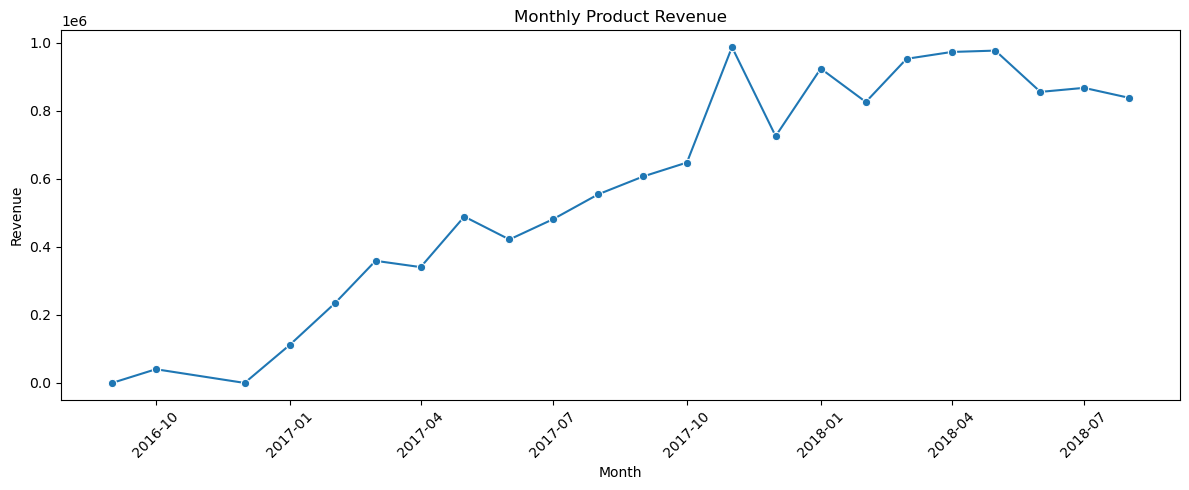

In [40]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=monthly_performance,
    x="purchase_month",
    y="product_revenue",
    marker="o"
)

plt.title("Monthly Product Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Analyze Monthly Orders and Revenue

In [41]:
monthly_performance["revenue_growth_percent"] = (
    monthly_performance["product_revenue"]
    .pct_change()
    .mul(100)
)


In [42]:
category_performance = (
    delivered_items.groupby("product_category_name_english")
    .agg(
        orders=("order_id", "nunique"),
        items_sold=("order_item_id", "count"),
        product_revenue=("price", "sum"),
        freight_value=("freight_value", "sum"),
        average_item_price=("price", "mean")
    )
    .reset_index()
    .sort_values("product_revenue", ascending=False)
)

category_performance.head(10)


,product_category_name_english,orders,items_sold,product_revenue,freight_value,average_item_price
43,health_beauty,8647,9465,1233131.72,178957.81,130.283330
73,watches_gifts,5495,5859,1166176.98,98156.14,199.040276
7,bed_bath_table,9272,10953,1023434.76,201774.50,93.438762
67,sports_leisure,7530,8431,954852.55,163404.36,113.254958
15,computers_accessories,6530,7644,888724.61,143999.16,116.264339
39,furniture_decor,6307,8160,711927.69,168402.23,87.246040
49,housewares,5743,6795,615628.69,142763.56,90.600249
20,cool_stuff,3559,3718,610204.10,81476.79,164.121598
5,auto,3810,4140,578966.65,90488.10,139.847017
71,toys,3804,4030,471286.48,75774.58,116.944536


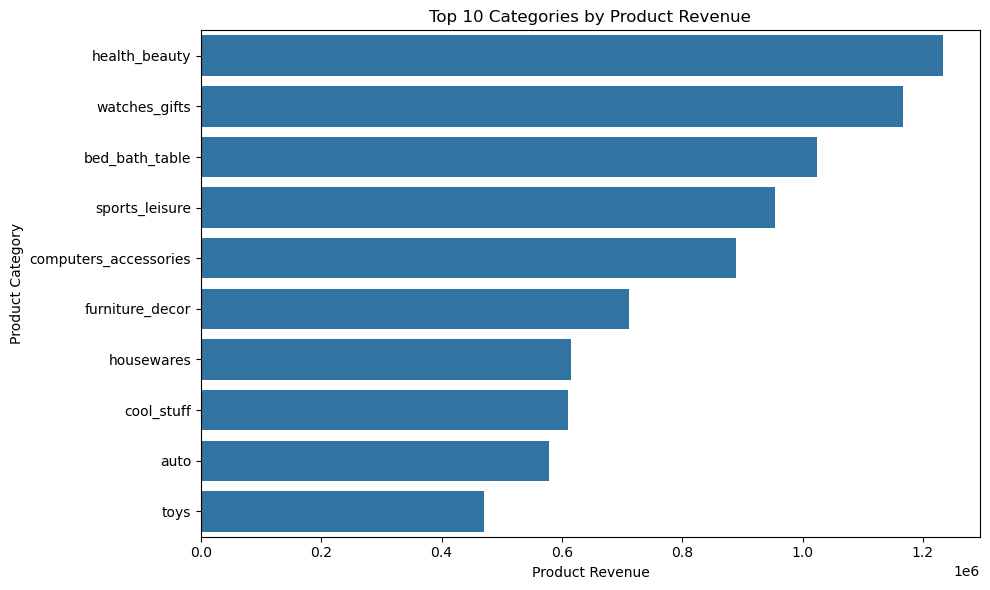

In [43]:
top_categories = category_performance.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_categories,
    x="product_revenue",
    y="product_category_name_english"
)

plt.title("Top 10 Categories by Product Revenue")
plt.xlabel("Product Revenue")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()


# Analyze Customers

In [44]:
customer_summary = (
    order_level.groupby("customer_unique_id")
    .agg(
        orders=("order_id", "nunique"),
        first_order=("order_purchase_timestamp", "min"),
        last_order=("order_purchase_timestamp", "max")
    )
    .reset_index()
)

customer_summary["customer_type"] = np.where(
    customer_summary["orders"] > 1,
    "Repeat",
    "One-time"
)


In [45]:
repeat_customer_rate = (
    customer_summary["orders"].gt(1).mean() * 100
)

print(f"Repeat customer rate: {repeat_customer_rate:.2f}%")


Repeat customer rate: 3.12%


# Customer geography

In [ ]:

customers_by_state = (
    order_level.groupby("customer_state")
    .agg(
        orders=("order_id", "nunique"),
        customers=("customer_unique_id", "nunique")
    )
    .reset_index()
    .sort_values("orders", ascending=False)
)

customers_by_state.head(10)

# Analyze Delivery Performance

In [47]:
delivery_analysis = order_level[
    (order_level["order_status"] == "delivered")
    & order_level["order_delivered_customer_date"].notna()
    & order_level["order_estimated_delivery_date"].notna()
].copy()


In [48]:
delivery_analysis["delivery_days"] = (
    delivery_analysis["order_delivered_customer_date"]
    - delivery_analysis["order_purchase_timestamp"]
).dt.total_seconds() / 86400

delivery_analysis["days_vs_estimate"] = (
    delivery_analysis["order_delivered_customer_date"]
    - delivery_analysis["order_estimated_delivery_date"]
).dt.total_seconds() / 86400

delivery_analysis["is_late"] = (
    delivery_analysis["days_vs_estimate"] > 0
)

print("Average delivery days:",
      delivery_analysis["delivery_days"].mean())

print("Late delivery rate:",
      delivery_analysis["is_late"].mean() * 100)


Average delivery days: 12.558217098051975
Late delivery rate: 8.112366538820359


In [49]:
delivery_by_state = (
    delivery_analysis.groupby("customer_state")
    .agg(
        orders=("order_id", "nunique"),
        average_delivery_days=("delivery_days", "mean"),
        late_delivery_rate=("is_late", "mean"),
        average_review_score=("review_score", "mean")
    )
    .reset_index()
)

delivery_by_state["late_delivery_rate"] *= 100

delivery_by_state.sort_values(
    "late_delivery_rate",
    ascending=False
).head(10)


,customer_state,orders,average_delivery_days,late_delivery_rate,average_review_score
1,AL,397,24.543855,23.929471,3.852792
9,MA,717,21.572976,19.665272,3.833567
16,PI,476,19.457098,15.966387,3.993631
5,CE,1279,21.266579,15.324472,3.941870
24,SE,335,21.519788,15.223881,3.907186
4,BA,3256,19.335466,14.035627,3.930009
18,RJ,12350,15.309438,13.473684,3.965141
26,TO,274,17.658063,12.773723,4.153846
13,PA,946,23.772917,12.367865,3.909968
7,ES,1995,15.789307,12.230576,4.079736


# Analyze Reviews and Delivery

In [50]:
delivery_analysis["delivery_status"] = np.where(
    delivery_analysis["is_late"],
    "Late",
    "On time or early"
)


In [51]:
review_by_delivery = (
    delivery_analysis.groupby("delivery_status")
    .agg(
        orders=("order_id", "nunique"),
        average_review_score=("review_score", "mean"),
        low_review_rate=(
            "review_score",
            lambda x: x.le(2).mean() * 100
        )
    )
    .reset_index()
)

review_by_delivery


,delivery_status,orders,average_review_score,low_review_rate
0,Late,7826,2.566506,52.849476
1,On time or early,88644,4.294292,9.137674


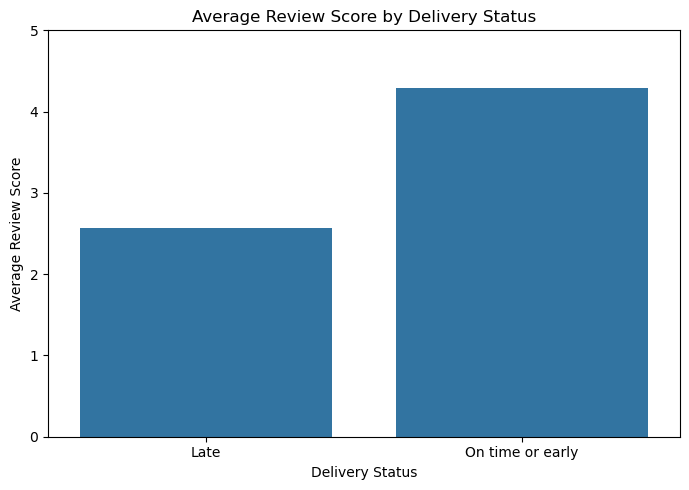

In [52]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=review_by_delivery,
    x="delivery_status",
    y="average_review_score"
)

plt.title("Average Review Score by Delivery Status")
plt.xlabel("Delivery Status")
plt.ylabel("Average Review Score")
plt.ylim(0, 5)
plt.tight_layout()
plt.show()


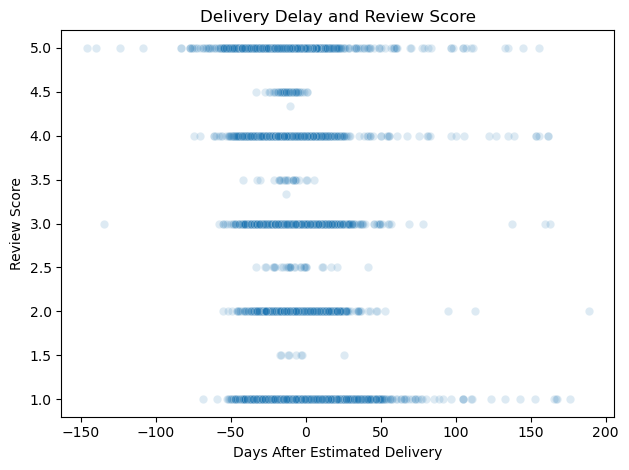

In [53]:
sns.scatterplot(
    data=delivery_analysis,
    x="days_vs_estimate",
    y="review_score",
    alpha=0.15
)

plt.title("Delivery Delay and Review Score")
plt.xlabel("Days After Estimated Delivery")
plt.ylabel("Review Score")
plt.tight_layout()
plt.show()


# Analyze Sellers

In [54]:
seller_performance = (
    delivered_items.groupby("seller_id")
    .agg(
        orders=("order_id", "nunique"),
        items_sold=("order_item_id", "count"),
        product_revenue=("price", "sum"),
        average_freight=("freight_value", "mean")
    )
    .reset_index()
)


In [55]:
seller_order_map = (
    order_items[["order_id", "seller_id"]]
    .drop_duplicates()
    .merge(
        delivery_analysis[
            ["order_id", "is_late", "review_score"]
        ],
        on="order_id",
        how="inner"
    )
)

seller_service = (
    seller_order_map.groupby("seller_id")
    .agg(
        evaluated_orders=("order_id", "nunique"),
        late_delivery_rate=("is_late", "mean"),
        average_review_score=("review_score", "mean")
    )
    .reset_index()
)

seller_service["late_delivery_rate"] *= 100

seller_performance = seller_performance.merge(
    seller_service,
    on="seller_id",
    how="left",
    validate="one_to_one"
)


In [56]:
established_sellers = seller_performance[
    seller_performance["evaluated_orders"] >= 20
].copy()

at_risk_sellers = established_sellers[
    (established_sellers["late_delivery_rate"] > 20)
    | (established_sellers["average_review_score"] < 3.5)
].sort_values(
    ["late_delivery_rate", "average_review_score"],
    ascending=[False, True]
)

at_risk_sellers.head(10)


,seller_id,orders,items_sold,product_revenue,average_freight,evaluated_orders,late_delivery_rate,average_review_score
2873,f76a3b1349b6df1ee875d1f3fa4340f0,24,24,4160.79,24.507917,24,37.500000,3.458333
1543,821fb029fc6e495ca4f08a35d51e53a5,24,25,17851.62,54.622000,24,37.500000,3.478261
2766,ede0c03645598cdfc63ca8237acbe73d,43,47,2352.15,15.070213,43,34.883721,3.571429
2011,ad781527c93d00d89a11eecd9dcad7c1,38,38,6039.63,57.197105,38,31.578947,3.342105
1556,835f0f7810c76831d6c7d24c7a646d4d,42,48,4990.20,19.417708,42,30.952381,3.357143
1000,54965bbe3e4f07ae045b90b0b8541f52,73,81,10351.70,25.632840,73,30.136986,3.144928
57,054694fa03fe82cec4b7551487331d74,20,21,8286.10,31.440000,20,30.000000,3.400000
1509,7f152321c60a266edc53af1925ef96c1,20,20,3919.80,27.606000,20,30.000000,3.800000
914,4e5725ba188db8252977a4f0227bd462,21,24,1865.09,15.177917,21,28.571429,3.523810
478,2a1348e9addc1af5aaa619b1a3679d6b,48,51,2697.40,14.262157,48,27.083333,3.170213


# Analyze Payment Behavior

In [57]:
payment_per_order = (
    payments.groupby("order_id")
    .agg(
        payment_value=("payment_value", "sum"),
        payment_records=("payment_sequential", "count"),
        maximum_installments=("payment_installments", "max")
    )
    .reset_index()
)


In [58]:

payment_type_summary = (
    payments.groupby("payment_type")
    .agg(
        payment_records=("order_id", "count"),
        orders=("order_id", "nunique"),
        payment_value=("payment_value", "sum"),
        average_installments=("payment_installments", "mean")
    )
    .reset_index()
    .sort_values("payment_value", ascending=False)
)

payment_type_summary


,payment_type,payment_records,orders,payment_value,average_installments
1,credit_card,76795,76505,12542084.19,3.507155
0,boleto,19784,19784,2869361.27,1.000000
4,voucher,5775,3866,379436.87,1.000000
2,debit_card,1529,1528,217989.79,1.000000
3,not_defined,3,3,0.00,1.000000


# Optional Advanced Analysis: RFM Segmentation
- Recency: How recently the customer purchased.
- Frequency: How many orders they made.
- Monetary: How much they spent.

In [59]:
delivered_orders = orders[
    orders["order_status"] == "delivered"
][["order_id", "customer_id", "order_purchase_timestamp"]]

customer_transactions = (
    delivered_orders
    .merge(
        customers[["customer_id", "customer_unique_id"]],
        on="customer_id",
        how="left",
        validate="many_to_one"
    )
    .merge(
        payment_per_order[["order_id", "payment_value"]],
        on="order_id",
        how="left",
        validate="one_to_one"
    )
)


In [60]:
snapshot_date = (
    customer_transactions["order_purchase_timestamp"].max()
    + pd.Timedelta(days=1)
)

rfm = (
    customer_transactions.groupby("customer_unique_id")
    .agg(
        recency=(
            "order_purchase_timestamp",
            lambda x: (snapshot_date - x.max()).days
        ),
        frequency=("order_id", "nunique"),
        monetary=("payment_value", "sum")
    )
    .reset_index()
)

rfm.head()


,customer_unique_id,recency,frequency,monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19
2,0000f46a3911fa3c0805444483337064,537,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89


# Validate Your Results

In [64]:
assert orders["order_id"].is_unique
assert order_level["order_id"].is_unique
assert len(order_level) == len(orders)


In [65]:
original_item_revenue = order_items["price"].sum()
modeled_item_revenue = item_level["price"].sum()

print(original_item_revenue)
print(modeled_item_revenue)

assert np.isclose(original_item_revenue, modeled_item_revenue)


13591643.700000003
13591643.700000003


In [66]:
invalid_delivery_dates = delivery_analysis[
    delivery_analysis["order_delivered_customer_date"]
    < delivery_analysis["order_purchase_timestamp"]
]

print("Invalid delivery records:", len(invalid_delivery_dates))


Invalid delivery records: 0


In [67]:
delivery_analysis["delivery_days"].describe(
    percentiles=[0.01, 0.5, 0.95, 0.99]
)


count    96470.000000
mean        12.558217
std          9.546156
min          0.533414
1%           1.825151
50%         10.217477
95%         29.274046
99%         46.050262
max        209.628611
Name: delivery_days, dtype: float64

# Pareto 80/20 Rule

In [68]:
# محاسبه سهم انباشته درآمد فروشندگان
seller_revenue = order_items.groupby("seller_id")["price"].sum().sort_values(ascending=False).reset_index()
seller_revenue["cum_percentage"] = seller_revenue["price"].cumsum() / seller_revenue["price"].sum() * 100
seller_revenue["cum_sellers_pct"] = (seller_revenue.index + 1) / len(seller_revenue) * 100

# پیدا کردن نقطه‌ای که ۸۰٪ درآمد را پوشش می‌دهد
sellers_for_80_pct = seller_revenue[seller_revenue["cum_percentage"] <= 80]
print(f"فقط {sellers_for_80_pct.shape[0]} فروشنده ({sellers_for_80_pct['cum_sellers_pct'].max():.2f} درصد از کل) حدود ۸۰٪ درآمد را تامین می‌کنند.")


فقط 543 فروشنده (17.54 درصد از کل) حدود ۸۰٪ درآمد را تامین می‌کنند.


# Freight Ratio Analysis

In [69]:
# محاسبه نسبت هزینه ارسال به تفکیک ایالت
geo_freight = order_items.merge(orders, on="order_id").merge(customers, on="customer_id")
state_freight = geo_freight.groupby("customer_state").agg(
    total_revenue=("price", "sum"),
    total_freight=("freight_value", "sum")
).reset_index()

state_freight["freight_ratio"] = (state_freight["total_freight"] / state_freight["total_revenue"]) * 100
state_freight.sort_values("freight_ratio", ascending=False).head(10)


,customer_state,total_revenue,total_freight,freight_ratio
21,RR,7829.43,2235.19,28.548566
9,MA,119648.22,31523.77,26.347045
20,RO,46140.64,11417.38,24.744737
2,AM,22356.84,5478.89,24.506549
16,PI,86914.08,21218.20,24.412845
24,SE,58920.85,14111.47,23.949875
26,TO,49621.74,11732.68,23.644233
0,AC,15982.95,3686.75,23.066768
19,RN,83034.98,18860.10,22.713440
15,PE,262788.03,59449.66,22.622667


# Review Score vs. Delivery Delay

In [70]:
# محاسبه تاخیر واقعی تحویل
orders["estimated_delivery_dt"] = pd.to_datetime(orders["order_estimated_delivery_date"])
orders["actual_delivery_dt"] = pd.to_datetime(orders["order_delivered_customer_date"])
orders["delivery_delay_days"] = (orders["actual_delivery_dt"] - orders["estimated_delivery_dt"]).dt.days

# ادغام با امتیازها (فرض بر وجود review_df)
delay_reviews = orders.merge(reviews_agg, on="order_id", how="inner")

# گروه‌بندی بر اساس میزان تاخیر (مثلاً به موقع، تا ۳ روز تاخیر، بیشتر از ۳ روز تاخیر)
def classify_delay(days):
    if pd.isna(days): return "نامشخص/تحویل‌نشده"
    if days <= 0: return "به موقع یا زودتر"
    elif days <= 3: return "تاخیر جزیی (۱-۳ روز)"
    else: return "تاخیر جدی (بیشتر از ۳ روز)"

delay_reviews["delay_class"] = delay_reviews["delivery_delay_days"].apply(classify_delay)
delay_reviews.groupby("delay_class")["review_score"].mean().reset_index()


,delay_class,review_score
0,به موقع یا زودتر,4.290450
1,تاخیر جدی (بیشتر از ۳ روز),1.855298
2,تاخیر جزیی (۱-۳ روز),3.291037
3,نامشخص/تحویل‌نشده,1.753254


# Customer Retention & Repeat Purchase

In [72]:
# شمارش تعداد سفارش‌های ثبت شده توسط هر مشتری یکتا (customer_unique_id)
customer_orders = orders.merge(customers, on="customer_id").groupby("customer_unique_id")["order_id"].nunique()
repeat_customers_pct = (customer_orders > 1).sum() / len(customer_orders) * 100
print(f"نرخ خریداران وفادار (بیشتر از ۱ بار خرید): {repeat_customers_pct:.2f}%")


نرخ خریداران وفادار (بیشتر از ۱ بار خرید): 3.12%


# Insights

In [73]:
import pandas as pd
import numpy as np

# 1) آماده‌سازی تاریخ‌ها
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]

for col in date_cols:
    if col in orders.columns:
        orders[col] = pd.to_datetime(orders[col], errors="coerce")

# 2) پیدا کردن دیتافریم review
review_df = None
for name in ["order_reviews", "reviews", "df_order_reviews", "order_reviews_df"]:
    if name in globals():
        review_df = globals()[name].copy()
        print(f"Using review dataframe: {name}")
        break

if review_df is None:
    raise NameError(
        "Review dataframe not found. Expected one of: "
        "order_reviews, reviews, df_order_reviews, order_reviews_df"
    )

# 3) تجمیع review در سطح order
reviews_agg = (
    review_df.groupby("order_id", as_index=False)
    .agg(review_score=("review_score", "mean"))
)

# 4) محاسبه تاخیر تحویل
orders_delay = orders.copy()

orders_delay["delivery_delay_days"] = (
    orders_delay["order_delivered_customer_date"] -
    orders_delay["order_estimated_delivery_date"]
).dt.days

orders_delay["actual_delivery_days"] = (
    orders_delay["order_delivered_customer_date"] -
    orders_delay["order_purchase_timestamp"]
).dt.days

# 5) فقط سفارش‌هایی که واقعاً تحویل شده‌اند
delivered_orders = orders_delay[
    orders_delay["order_status"] == "delivered"
].copy()

# 6) اتصال review
delay_reviews = delivered_orders.merge(
    reviews_agg,
    on="order_id",
    how="left"
)

# 7) دسته‌بندی تاخیر
def classify_delay(days):
    if pd.isna(days):
        return "unknown"
    elif days <= 0:
        return "on_time_or_early"
    elif days <= 3:
        return "1_3_days_late"
    elif days <= 7:
        return "4_7_days_late"
    else:
        return "8plus_days_late"

delay_reviews["delay_bucket"] = delay_reviews["delivery_delay_days"].apply(classify_delay)

# 8) خلاصه آماری
delay_review_summary = (
    delay_reviews.groupby("delay_bucket", as_index=False)
    .agg(
        orders=("order_id", "nunique"),
        reviewed_orders=("review_score", lambda s: s.notna().sum()),
        avg_review_score=("review_score", "mean"),
        median_review_score=("review_score", "median"),
        avg_delay_days=("delivery_delay_days", "mean"),
        avg_actual_delivery_days=("actual_delivery_days", "mean"),
    )
)

delay_review_summary["review_coverage"] = (
    delay_review_summary["reviewed_orders"] / delay_review_summary["orders"] * 100
)

# مرتب‌سازی منطقی
bucket_order = [
    "on_time_or_early",
    "1_3_days_late",
    "4_7_days_late",
    "8plus_days_late",
    "unknown",
]

delay_review_summary["delay_bucket"] = pd.Categorical(
    delay_review_summary["delay_bucket"],
    categories=bucket_order,
    ordered=True
)

delay_review_summary = delay_review_summary.sort_values("delay_bucket")

delay_review_summary


Using review dataframe: order_reviews


,delay_bucket,orders,reviewed_orders,avg_review_score,median_review_score,avg_delay_days,avg_actual_delivery_days,review_coverage
3,on_time_or_early,89936,89443,4.290589,5.0,-13.510263,10.539261,99.451832
0,1_3_days_late,1870,1852,3.291037,4.0,1.826203,22.852406,99.037433
1,4_7_days_late,1802,1748,2.105549,1.0,5.517203,27.770255,97.003330
2,8plus_days_late,2862,2781,1.697591,1.0,19.578966,44.037386,97.169811
4,unknown,8,8,4.500000,5.0,NaN,NaN,100.000000


In [74]:
delay_reviews["low_review_flag"] = delay_reviews["review_score"].le(2)

low_review_by_delay = (
    delay_reviews.groupby("delay_bucket", as_index=False)
    .agg(
        orders=("order_id", "nunique"),
        low_review_orders=("low_review_flag", "sum"),
        avg_review_score=("review_score", "mean")
    )
)

low_review_by_delay["low_review_rate"] = (
    low_review_by_delay["low_review_orders"] / low_review_by_delay["orders"] * 100
)

low_review_by_delay["delay_bucket"] = pd.Categorical(
    low_review_by_delay["delay_bucket"],
    categories=bucket_order,
    ordered=True
)

low_review_by_delay = low_review_by_delay.sort_values("delay_bucket")

low_review_by_delay


,delay_bucket,orders,low_review_orders,avg_review_score,low_review_rate
3,on_time_or_early,89936,8257,4.290589,9.180973
0,1_3_days_late,1870,596,3.291037,31.871658
1,4_7_days_late,1802,1181,2.105549,65.538291
2,8plus_days_late,2862,2202,1.697591,76.939203
4,unknown,8,1,4.500000,12.500000


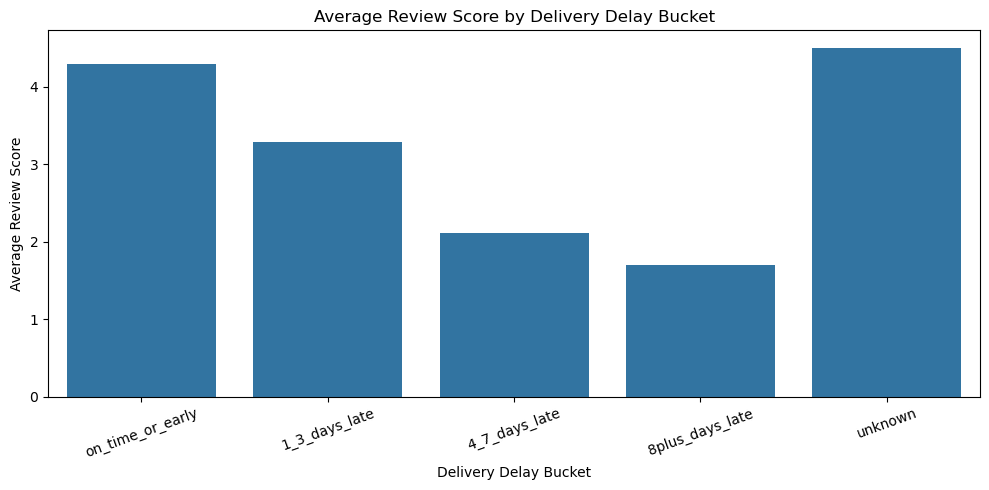

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.barplot(
    data=delay_review_summary,
    x="delay_bucket",
    y="avg_review_score"
)
plt.title("Average Review Score by Delivery Delay Bucket")
plt.xlabel("Delivery Delay Bucket")
plt.ylabel("Average Review Score")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


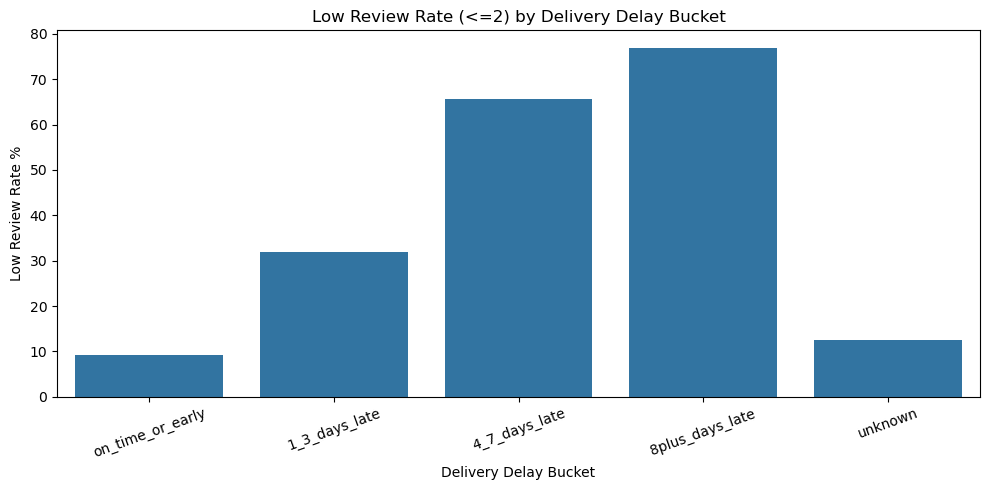

In [76]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=low_review_by_delay,
    x="delay_bucket",
    y="low_review_rate"
)
plt.title("Low Review Rate (<=2) by Delivery Delay Bucket")
plt.xlabel("Delivery Delay Bucket")
plt.ylabel("Low Review Rate %")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


# repeat purchase / customer retention

In [77]:
import pandas as pd
import numpy as np

# 1) آماده‌سازی ستون‌های لازم
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"], errors="coerce"
)

customer_orders = (
    orders[["order_id", "customer_id", "order_purchase_timestamp", "order_status"]]
    .merge(
        customers[["customer_id", "customer_unique_id"]],
        on="customer_id",
        how="left"
    )
    .dropna(subset=["customer_unique_id"])
    .copy()
)

# 2) فقط سفارش‌های معتبر برای retention
# اگر خواستی می‌توانی فقط delivered را نگه داری
valid_statuses = ["delivered", "shipped", "invoiced", "processing", "approved"]
customer_orders = customer_orders[
    customer_orders["order_status"].isin(valid_statuses)
].copy()

customer_orders["purchase_month"] = (
    customer_orders["order_purchase_timestamp"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

# 3) تعداد سفارش به ازای هر مشتری
customer_order_counts = (
    customer_orders
    .groupby("customer_unique_id", as_index=False)
    .agg(
        total_orders=("order_id", "nunique"),
        first_purchase=("order_purchase_timestamp", "min"),
        last_purchase=("order_purchase_timestamp", "max")
    )
)

customer_order_counts["is_repeat_customer"] = customer_order_counts["total_orders"] > 1

repeat_purchase_rate = (
    customer_order_counts["is_repeat_customer"].mean() * 100
)

repeat_purchase_rate


3.0393952793043186

In [78]:
retention_summary = pd.DataFrame({
    "total_customers": [customer_order_counts["customer_unique_id"].nunique()],
    "repeat_customers": [customer_order_counts["is_repeat_customer"].sum()],
    "repeat_purchase_rate": [repeat_purchase_rate]
})

retention_summary


,total_customers,repeat_customers,repeat_purchase_rate
0,94986,2887,3.039395


In [79]:
purchase_frequency_dist = (
    customer_order_counts["total_orders"]
    .value_counts(dropna=False)
    .sort_index()
    .reset_index()
)

purchase_frequency_dist.columns = ["total_orders", "customers"]
purchase_frequency_dist["customer_share_pct"] = (
    purchase_frequency_dist["customers"] / purchase_frequency_dist["customers"].sum() * 100
)

purchase_frequency_dist


,total_orders,customers,customer_share_pct
0,1,92099,96.960605
1,2,2651,2.790938
2,3,188,0.197924
3,4,29,0.030531
4,5,9,0.009475
5,6,5,0.005264
6,7,3,0.003158
7,9,1,0.001053
8,16,1,0.001053


# Cohort Analysis

In [80]:
customer_first_month = (
    customer_orders
    .groupby("customer_unique_id", as_index=False)
    .agg(first_purchase_month=("purchase_month", "min"))
)

customer_orders_cohort = customer_orders.merge(
    customer_first_month,
    on="customer_unique_id",
    how="left"
)

cohort_sizes = (
    customer_orders_cohort
    .groupby("first_purchase_month", as_index=False)
    .agg(customers=("customer_unique_id", "nunique"))
)

repeat_by_cohort = (
    customer_orders_cohort
    .groupby(["first_purchase_month", "customer_unique_id"], as_index=False)
    .agg(total_orders=("order_id", "nunique"))
)

repeat_by_cohort["is_repeat_customer"] = repeat_by_cohort["total_orders"] > 1

cohort_repeat = (
    repeat_by_cohort
    .groupby("first_purchase_month", as_index=False)
    .agg(
        customers=("customer_unique_id", "nunique"),
        repeat_customers=("is_repeat_customer", "sum")
    )
)

cohort_repeat["repeat_rate_pct"] = (
    cohort_repeat["repeat_customers"] / cohort_repeat["customers"] * 100
)

cohort_repeat = cohort_repeat.sort_values("first_purchase_month")
cohort_repeat


,first_purchase_month,customers,repeat_customers,repeat_rate_pct
0,2016-09-01,2,0,0.000000
1,2016-10-01,290,12,4.137931
2,2016-12-01,1,1,100.000000
3,2017-01-01,752,55,7.313830
4,2017-02-01,1690,70,4.142012
5,2017-03-01,2571,129,5.017503
6,2017-04-01,2325,106,4.559140
7,2017-05-01,3541,189,5.337475
8,2017-06-01,3102,167,5.383623
9,2017-07-01,3822,179,4.683412


# retension

In [81]:
customer_month_activity = (
    customer_orders[["customer_unique_id", "purchase_month"]]
    .drop_duplicates()
    .sort_values(["customer_unique_id", "purchase_month"])
)

customer_month_activity["cohort_month"] = (
    customer_month_activity
    .groupby("customer_unique_id")["purchase_month"]
    .transform("min")
)

customer_month_activity["month_number"] = (
    (customer_month_activity["purchase_month"].dt.year - customer_month_activity["cohort_month"].dt.year) * 12
    + (customer_month_activity["purchase_month"].dt.month - customer_month_activity["cohort_month"].dt.month)
)

cohort_matrix = (
    customer_month_activity
    .groupby(["cohort_month", "month_number"], as_index=False)
    .agg(customers=("customer_unique_id", "nunique"))
)

cohort_size = (
    cohort_matrix[cohort_matrix["month_number"] == 0]
    .rename(columns={"customers": "cohort_size"})
    [["cohort_month", "cohort_size"]]
)

cohort_matrix = cohort_matrix.merge(cohort_size, on="cohort_month", how="left")
cohort_matrix["retention_rate_pct"] = (
    cohort_matrix["customers"] / cohort_matrix["cohort_size"] * 100
)

cohort_pivot = cohort_matrix.pivot(
    index="cohort_month",
    columns="month_number",
    values="retention_rate_pct"
)

cohort_pivot


month_number,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort_month,,,,,,,,,,,,,,,,,,,,
2016-09-01,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10-01,100.0,NaN,NaN,NaN,NaN,NaN,0.344828,NaN,NaN,0.344828,NaN,0.344828,NaN,0.344828,NaN,0.344828,NaN,0.344828,0.689655,0.689655
2016-12-01,100.0,100.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01-01,100.0,0.398936,0.265957,0.132979,0.398936,0.132979,0.398936,0.132979,0.132979,NaN,0.398936,0.132979,0.664894,0.398936,0.132979,0.132979,0.265957,0.398936,0.132979,NaN
2017-02-01,100.0,0.236686,0.295858,0.118343,0.414201,0.118343,0.236686,0.177515,0.118343,0.177515,0.118343,0.295858,0.118343,0.177515,0.118343,0.059172,0.059172,0.236686,NaN,NaN
2017-03-01,100.0,0.505640,0.350058,0.388954,0.350058,0.155581,0.155581,0.311163,0.350058,0.077791,0.388954,0.116686,0.233372,0.116686,0.155581,0.233372,0.077791,0.155581,NaN,NaN
2017-04-01,100.0,0.602151,0.215054,0.172043,0.301075,0.258065,0.344086,0.301075,0.301075,0.172043,0.258065,0.086022,0.086022,0.043011,0.086022,0.086022,0.129032,NaN,NaN,NaN
2017-05-01,100.0,0.480090,0.480090,0.395369,0.310647,0.338887,0.423609,0.141203,0.254165,0.254165,0.254165,0.338887,0.254165,0.028241,0.197684,0.225925,NaN,NaN,NaN,NaN
2017-06-01,100.0,0.451322,0.354610,0.386847,0.257898,0.386847,0.354610,0.225661,0.128949,0.225661,0.322373,0.322373,0.161186,0.128949,0.193424,NaN,NaN,NaN,NaN,NaN


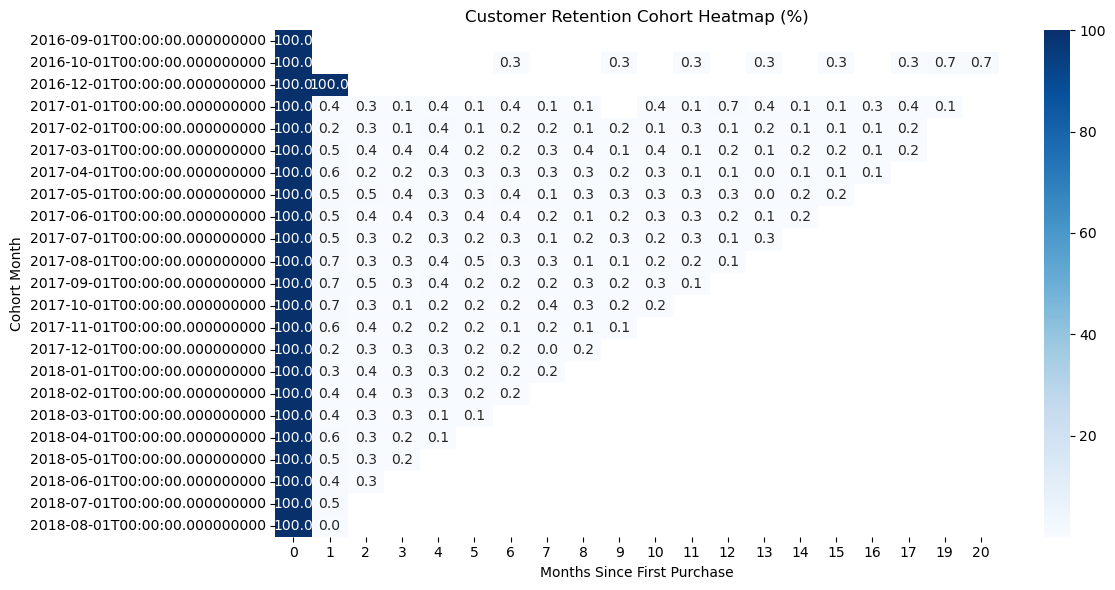

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.heatmap(cohort_pivot, annot=True, fmt=".1f", cmap="Blues")
plt.title("Customer Retention Cohort Heatmap (%)")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Cohort Month")
plt.tight_layout()
plt.show()


# Feature Engineering

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.92      0.90      0.91     16718
           1       0.41      0.50      0.45      2447

    accuracy                           0.85     19165
   macro avg       0.67      0.70      0.68     19165
weighted avg       0.86      0.85      0.85     19165

ROC-AUC Score: 0.75


C:\Users\Asus\AppData\Local\Temp\ipykernel_23972\3952171197.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=[features[i] for i in indices], palette='viridis')


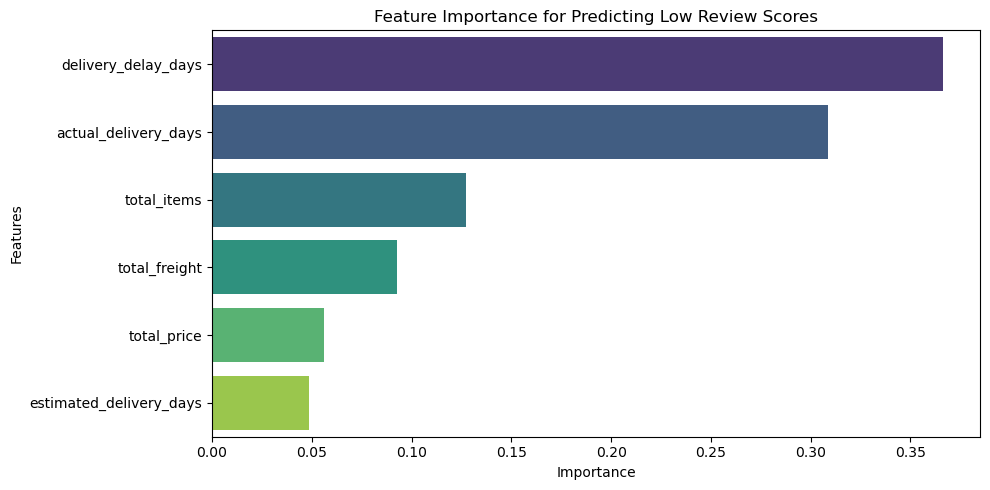

In [83]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ۱. ادغام و آماده‌سازی داده‌ها
# مطمئن شو که دیتافریم‌های orders، order_items و reviews قبلاً لود شده‌اند

# تجمیع آیتم‌های سفارش برای محاسبه قیمت کل و هزینه ارسال کل در هر سفارش
items_agg = order_items.groupby('order_id').agg(
    total_price=('price', 'sum'),
    total_freight=('freight_value', 'sum'),
    total_items=('order_item_id', 'max')
).reset_index()

# آماده‌سازی ستون‌های تاریخ سفارشات
date_cols = ['order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date']
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')

# محاسبه متغیرهای زمانی
orders_features = orders.copy()
orders_features['actual_delivery_days'] = (
    orders_features['order_delivered_customer_date'] - orders_features['order_purchase_timestamp']
).dt.days

orders_features['estimated_delivery_days'] = (
    orders_features['order_estimated_delivery_date'] - orders_features['order_purchase_timestamp']
).dt.days

orders_features['delivery_delay_days'] = (
    orders_features['order_delivered_customer_date'] - orders_features['order_estimated_delivery_date']
).dt.days

# فقط سفارش‌های تحویل داده شده را نگه می‌داریم
df_model = orders_features[orders_features['order_status'] == 'delivered'].copy()

# ادغام با آیتم‌ها
df_model = df_model.merge(items_agg, on='order_id', how='inner')

# ادغام با امتیازها
reviews_agg = order_reviews.groupby('order_id').agg(review_score=('review_score', 'mean')).reset_index()
df_model = df_model.merge(reviews_agg, on='order_id', how='inner')

# حذف مقادیر خالی در ویژگی‌های اصلی
df_model = df_model.dropna(subset=['actual_delivery_days', 'delivery_delay_days'])

# ۲. ساخت متغیر هدف (Target Variable)
# امتیاز ۱ و ۲ به عنوان Low Review (پرریسک) در نظر گرفته می‌شود
df_model['low_review_flag'] = (df_model['review_score'] <= 2).astype(int)

# ۳. انتخاب ویژگی‌ها (Features) و متغیر هدف (Target)
features = [
    'actual_delivery_days', 
    'estimated_delivery_days', 
    'delivery_delay_days', 
    'total_price', 
    'total_freight', 
    'total_items'
]

X = df_model[features]
y = df_model['low_review_flag']

# تقسیم داده‌ها به آموزش و تست (۸۰٪ آموزش، ۲۰٪ تست)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ۴. آموزش مدل Random Forest
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

# ۵. پیش‌بینی و ارزیابی
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

print("--- Classification Report ---")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.2f}")

# ۶. استخراج اهمیت ویژگی‌ها (Feature Importance)
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 5))
sns.barplot(x=importances[indices], y=[features[i] for i in indices], palette='viridis')
plt.title('Feature Importance for Predicting Low Review Scores')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.tight_layout()
plt.show()
